# DCB benchmark: Alfano and Crisfield (2001)

G. Alfano and M. A. Crisfield, *Finite element interface models for the delamination analysis of laminated composites: mechanical and computational issues*, Int. J. Numer. Meth. Engng 2001; 50:1701-1736.

DCB cases of Section 5.1:

- Fig. 11, Table I: DCB of $L = 100$ mm, $a_0 = 30$ mm, total thickness $h = 3$ mm (arms of 1.5 mm), width 20 mm, far end clamped, 2D plane strain. Interface model (Fig. 12, mesh 4x400 Q8 with 280 INT6, $t_o = 57$ MPa), virtual crack closure (VCC, Fig. 12) and a low strength $t_o = 1.7$ MPa (Fig. 15a, mesh 4x100 Q8 with 70 INT6, tangent predictor).
- Table II, Fig. 23: XAS-913C DCB of width 30 mm, same geometry otherwise, interface model and experiments of Robinson and Song (1993).
- Fig. 22: isotropic DCB ($E = 210$ GPa, $\nu = 0.3$) compared with an analytical solution. The interface parameters are not given for this case, so it is only listed.

**Conventions.** The paper plots the reaction $R$ at the loaded point against the displacement $u$ of each arm, the two arms moving $\pm u$. Here all curves are given against the opening $\delta = 2u$.

**Digitised data.** The curves were read from the figures of the paper by eye, with an estimated uncertainty of $\pm 0.05$ mm in $u$ ($\pm 0.1$ mm in $\delta$) and $\pm 2$ N in $R$. Only the peak loads read from the figures are used in the comparison of peak values; the analytical LEFM curves below are exact and serve as a second reference.

In [1]:
import os
import sys

import numpy as np
import matplotlib.pyplot as plt
from IPython.display import Markdown, display

sys.path.insert(0, os.path.abspath('.'))
import dcb_utils as du

# True runs panels again, otherwise the results saved in RESULTS are loaded
RERUN = False
RESULTS = 'results'


## FE-based DCB cases

In [2]:
u2d = lambda u: 2*np.asarray(u, dtype=float)

tableI = dict(E1=135300., E2=9000., nu12=0.24, G12=5200., h=1.5, b=20.,
              L=100., a0=30., G1c=0.28)

fe_cases = {
    'TableI_to57': dict(tableI, tau_o=57., k_o=57./1e-7,
        label='Table I, $t_o$ = 57 MPa',
        source='Fig. 11, Table I, Fig. 12 (delta_o = 1e-7 mm)',
        model='2D plane strain, 4x400 Q8 + 280 INT6, quadratic arc length',
        curves={
            'interface model (Fig. 12)': (u2d([0, 1.0, 1.5, 2.0, 3.0, 4.0, 4.8]),
                                          np.array([0, 61.5, 52., 44., 35., 30.5, 28.])),
            'VCC (Fig. 12)': (u2d([0, 1.0, 2.0, 4.0, 6.0, 8.0, 9.0, 10.0, 11.5]),
                              np.array([0, 61., 44., 30., 25., 22., 22.5, 24.5, 28.])),
        },
        notes='The rise of the VCC curve after u = 8 mm is caused by the clamped far end.'),
    'TableI_to1.7': dict(tableI, tau_o=1.7, k_o=1.7/1e-7,
        label='Table I, $t_o$ = 1.7 MPa',
        source='Fig. 15a (tangent predictor, 37 increments)',
        model='2D plane strain, 4x100 Q8 + 70 INT6',
        curves={
            'interface model (Fig. 15a)': (u2d([0, 0.5, 0.9, 1.2, 1.45, 2.0, 3.0, 4.0, 6.0, 8.0, 10.0]),
                                           np.array([0, 24., 37., 45., 49.5, 46., 39., 33.5, 27., 23., 23.5])),
        },
        notes='Low strength: long process zone, too compliant before the peak (Section 5.1).'),
    'TableII_XAS913C': dict(E1=126000., E2=7500., nu12=0.263, G12=4981., h=1.5,
        b=30., L=100., a0=30., G1c=0.281, tau_o=57., k_o=57./1e-6,
        label='Table II, XAS-913C',
        source='Table II, Fig. 23 (delta_o = 1e-6 mm)',
        model='2D plane strain interface model',
        curves={
            'interface model (Fig. 23)': (u2d([0, 1.1, 1.5, 2.0, 3.0, 4.0, 5.0, 6.0, 7.0]),
                                          np.array([0, 90., 80., 70., 58., 49., 43., 39., 36.])),
        }),
    'isotropic': dict(E=2.1e5, nu=0.3, h=1.5, b=20., L=100., a0=30.,
        label='isotropic', source='Fig. 22',
        model='4x400 Q4 and Q4M + 70 INT4, compared with an analytical solution',
        curves={},
        notes='G_c and t_o not stated for this case: not simulated.'),
}


## Experimental DCB tests

In [3]:
exp_tests = {
    'XAS913C_Robinson_Song_1993': dict(
        fe_case='TableII_XAS913C',
        source='Robinson and Song (1993), J. Compos. Mater. 26:1554-1577, as plotted in Fig. 23',
        curves={
            'experiment (Fig. 23)': (u2d([1.35, 1.65, 1.95, 2.55, 3.0, 3.5, 4.2, 4.75, 5.4, 6.1]),
                                     np.array([88., 74., 69., 59., 55., 51., 43., 39., 39., 34.])),
        },
        notes='Only points on the propagation branch are plotted in the paper.'),
}


## panels model

The DCB is modelled with `dcb_utils.solve_dcb`: CLPT panels, far end clamped, arm tips opened symmetrically to $\pm\delta/2$ by prescribed displacements, a cohesive domain (`SB_TSL`, bilinear law) ahead of the initial crack front and a perfect bond (`SB`) over the rest of the bonded region. The load is the reaction of the prescribed displacement.

Discretisation, from the convergence study of `theory/multidomain_penalization/cohesive_zone_deviations_from_thesis.tex` (15 terms and 120 Gauss columns over the 17 mm cohesive domain of the reference DCB):

- terms along $x$ of the cohesive domain: $m = 1.5\,\lambda\,L_{tsl}$, with $\lambda = (k_o/4D_{11})^{1/4}$ the decay rate of the opening ahead of the process zone, at most 25;
- Gauss columns: $n_x = 10\,L_{tsl}/l_{cz}$, with $l_{cz} = 0.88\,E_2 G_{Ic}/\tau_o^2$ (Turon et al. 2007), which keeps about 6 points in the cohesive zone at the middle of the domain;
- the cohesive domain covers the crack growth up to the last opening plus a margin of $2\pi/\lambda + 3 l_{cz}$ for the process zone and the compressive lobe ahead of it; the opening range is limited so that $L_{tsl}$ stays below the length resolved with 25 terms.

The penalty stiffness is $k_o = 10^5$ N/mm$^3$ unless stated otherwise. Turon et al. (2007, Fig. 9) show that the load-displacement curve of the DCB does not change for $k_o \geq 10^4$ N/mm$^3$, and a lower $k_o$ gives a longer decay length $1/\lambda$, which the Ritz basis resolves with fewer terms.


In [4]:
def setup(case, k_o=1.e5, growth_max=None, n_steps=60, margin_factor=1.):
    """Cohesive domain, discretisation and openings of a panels run"""
    c = dict(case)
    c['k_o'] = k_o
    lam, lcz, L_max = du.resolution(c)
    margin = margin_factor*(2*np.pi/lam + 3*lcz)
    L_avail = c['L'] - c['a0']
    growth = min(L_max, L_avail) - margin
    if growth_max is not None:
        growth = min(growth, growth_max)
    L_tsl = min(growth + margin, L_avail)
    c = du.discretize(c, L_tsl)
    # opening when the crack reaches a0 + growth, corrected beam theory
    EI = du.D11(c)*c['b']
    dh = du.chi_williams(c['E1'], c['E2'], c['G12'])*c['h']
    ae = c['a0'] + growth + dh
    delta_max = 2/3*ae**2*np.sqrt(c['G1c']*c['b']/EI)
    openings = np.linspace(delta_max/n_steps, delta_max, n_steps)
    print(f"{case.get('label', '')}: lambda={lam:.3f} 1/mm, lcz={lcz:.2f} mm, "
          f"L_tsl={c['L_tsl']:.1f} mm, m_tsl={c['m_tsl']}, nx={c['nx']}, "
          f"delta_max={delta_max:.2f} mm")
    return c, openings


In [5]:
runs = {}
for key in ['TableI_to57', 'TableII_XAS913C']:
    case, openings = setup(fe_cases[key])
    runs[key] = (case, du.run_or_load(case, openings, f'{RESULTS}/alfano2001_{key}.npz',
                                      rerun=RERUN))


Table I, $t_o$ = 57 MPa: lambda=0.899 1/mm, lcz=0.68 mm, L_tsl=18.5 mm, m_tsl=25, nx=280, delta_max=3.22 mm
Table II, XAS-913C: lambda=0.916 1/mm, lcz=0.57 mm, L_tsl=18.2 mm, m_tsl=25, nx=300, delta_max=3.36 mm


The low strength case, $t_o = 1.7$ MPa, has a process zone of the order of the specimen length (slender-body estimate $(E_1 G_c/t_o^2)^{1/4} h^{3/4} \approx 15$ mm, Yang and Cox 2005), so the cohesive domain covers the whole bonded length. It is run with the maximum number of terms, up to an opening of 4 mm (the peak of Fig. 15a is at 2.9 mm), and is less converged than the other cases: almost every integration point is damaged, which makes each increment expensive.

In [6]:
case = dict(fe_cases['TableI_to1.7'])
case['k_o'] = 1.e5
case = du.discretize(case, case['L'] - case['a0'])
case['m_tsl'] = 25
openings = np.linspace(0.1, 4., 40)  # past the peak of Fig. 15a, delta = 2.9 mm
runs['TableI_to1.7'] = (case, du.run_or_load(case, openings,
                        f'{RESULTS}/alfano2001_TableI_to1.7.npz', rerun=RERUN))


## Comparison

### Table I, $t_o$ = 57 MPa

| curve | K0 (N/mm) | Pmax (N) | delta at Pmax (mm) | dK0, dPmax, d(delta) vs interface model (Fig. 12) | dK0, dPmax, d(delta) vs panels |
|---|---|---|---|---|---|
| interface model (Fig. 12) | 30.75 | 61.5 | 2.00 | - | -19.4%, -4.8%, +9.5% |
| VCC (Fig. 12) | 30.50 | 61.0 | 2.00 | -0.8%, -0.8%, +0.0% | -20.1%, -5.5%, +9.5% |
| panels | 38.15 | 64.6 | 1.83 | +24.1%, +5.0%, -8.7% | - |
| LEFM, simple beam theory | 42.44 | 68.9 | 1.62 | +38.0%, +12.1%, -18.8% | +11.3%, +6.8%, -11.0% |
| LEFM, corrected beam theory | 32.62 | 63.2 | 1.94 | +6.1%, +2.7%, -3.2% | -14.5%, -2.2%, +6.1% |

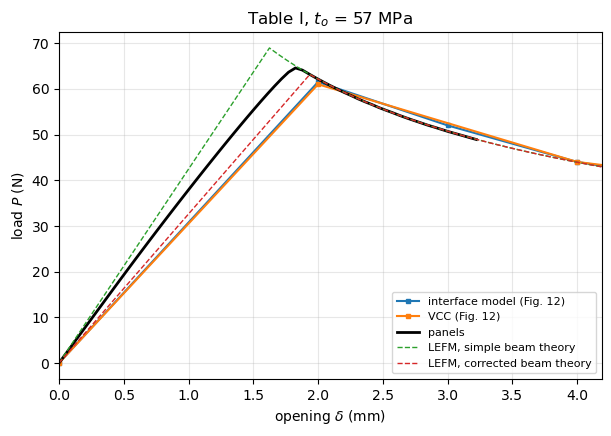

panels: 60 openings, 0 bisections, crack growth 10.5 mm, share of the load carried by the cohesive domain at the peak: 1.000


In [7]:
def compare(key, exp_key=None):
    fe = fe_cases[key]
    case, res = runs[key]
    rows = dict(fe['curves'])
    if exp_key is not None:
        rows.update(exp_tests[exp_key]['curves'])
    rows['panels'] = (np.concatenate(([0.], res['delta'])), np.concatenate(([0.], res['P'])))
    for corr, name in ((False, 'LEFM, simple beam theory'), (True, 'LEFM, corrected beam theory')):
        rows[name] = du.lefm_curve(fe, a_max=fe['a0'] + 60, corrected=corr)
    refs = [k for k in fe['curves']][:1]
    display(Markdown(f"### {fe['label']}\n\n" + du.markdown_table(rows, ref=refs + ['panels'])))
    fig, ax = plt.subplots(figsize=(7, 4.5))
    style = {k: dict(ls='none', marker='o', mfc='none') for k in rows if 'experiment' in k}
    style.update({k: dict(ls='--', lw=1) for k in rows if 'LEFM' in k})
    style.update({k: dict(marker='s', ms=3) for k in fe['curves']})
    style['panels'] = dict(lw=2, color='k')
    du.plot_curves(ax, rows, style)
    ax.set_xlim(0, max(res['delta'].max()*1.3, 4))
    ax.set_title(fe['label'])
    plt.show()
    print(f"panels: {len(res['delta'])} openings, {res['failed']} bisections, "
          f"crack growth {res['a'][-1] - fe['a0']:.1f} mm, "
          f"share of the load carried by the cohesive domain at the peak: "
          f"{res['P_traction'][np.argmax(res['P'])]/res['P'].max():.3f}")

compare('TableI_to57')


### Table I, $t_o$ = 1.7 MPa

| curve | K0 (N/mm) | Pmax (N) | delta at Pmax (mm) | dK0, dPmax, d(delta) vs interface model (Fig. 15a) | dK0, dPmax, d(delta) vs panels |
|---|---|---|---|---|---|
| interface model (Fig. 15a) | 24.00 | 49.5 | 2.90 | - | -3.1%, -2.8%, -0.0% |
| panels | 24.76 | 50.9 | 2.90 | +3.2%, +2.9%, +0.0% | - |
| LEFM, simple beam theory | 42.44 | 68.9 | 1.62 | +76.8%, +39.3%, -44.0% | +71.4%, +35.4%, -44.0% |
| LEFM, corrected beam theory | 32.62 | 63.2 | 1.94 | +35.9%, +27.6%, -33.2% | +31.7%, +24.0%, -33.2% |

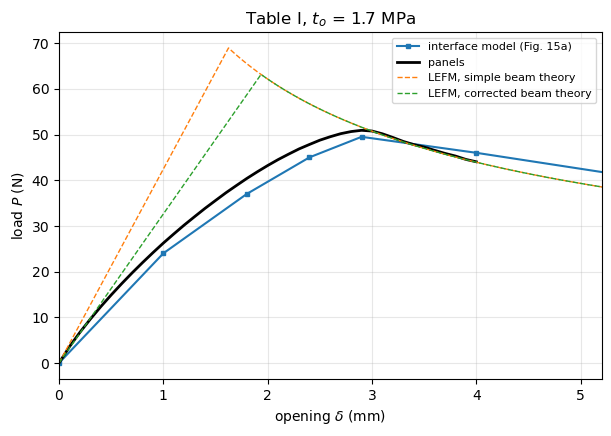

panels: 40 openings, 0 bisections, crack growth 5.8 mm, share of the load carried by the cohesive domain at the peak: 1.010


In [8]:
compare('TableI_to1.7')

### Table II, XAS-913C

| curve | K0 (N/mm) | Pmax (N) | delta at Pmax (mm) | dK0, dPmax, d(delta) vs interface model (Fig. 23) | dK0, dPmax, d(delta) vs panels |
|---|---|---|---|---|---|
| interface model (Fig. 23) | 40.91 | 90.0 | 2.20 | - | -23.4%, -4.0%, +15.4% |
| experiment (Fig. 23) | 32.59 | 88.0 | 2.70 | -20.3%, -2.2%, +22.7% | -39.0%, -6.2%, +41.7% |
| panels | 53.41 | 93.8 | 1.91 | +30.6%, +4.2%, -13.4% | - |
| LEFM, simple beam theory | 59.31 | 100.0 | 1.69 | +45.0%, +11.1%, -23.4% | +11.0%, +6.6%, -11.5% |
| LEFM, corrected beam theory | 45.62 | 91.6 | 2.01 | +11.5%, +1.8%, -8.7% | -14.6%, -2.3%, +5.4% |

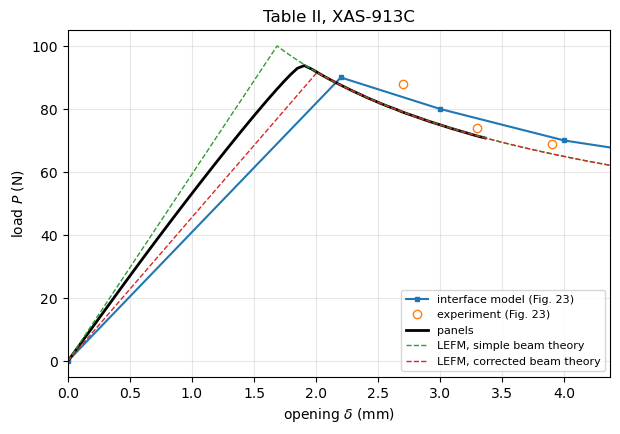

panels: 60 openings, 0 bisections, crack growth 10.6 mm, share of the load carried by the cohesive domain at the peak: 1.000


In [9]:
compare('TableII_XAS913C', 'XAS913C_Robinson_Song_1993')

**Remarks.**

- The penalty stiffness of the paper, $k_o = t_o/\delta_o$ with $\delta_o = 10^{-7}$ or $10^{-6}$ mm, is replaced by $10^5$ N/mm$^3$ (see above).
- The paper uses 2D plane strain continuum elements, which include transverse shear and the local deformation at the crack tip; the corrected beam theory reproduces these effects for a DCB. panels uses CLPT plates with a width of 20 or 30 mm and free edges.
- The digitised curves are approximate; compare peak loads within the reading uncertainty of about 2 N.

## Discussion

- **Table I, $t_o$ = 57 MPa.** panels predicts 64.6 N at an opening of 1.83 mm ($u$ = 0.92 mm), 5.0% above the interface model of the paper (about 61.5 N, Fig. 12) and 2.2% above the corrected beam theory (63.2 N). After the peak panels follows the LEFM propagation branch: 48.9 N against 49.0 N at $\delta$ = 3.22 mm, where the digitised FE curve gives about 50 N.
- **Table I, $t_o$ = 1.7 MPa.** With the low strength the process zone is of the order of the specimen length and the response departs from LEFM: the peak of the interface model (about 49.5 N at $\delta pprox$ 2.9 mm) is 22% below the corrected beam theory. panels reproduces it: 50.9 N at $\delta$ = 2.9 mm (+2.9%), with the same initial stiffness (+3.2%). This case tests the cohesive zone model itself rather than its LEFM limit.
- **XAS-913C.** panels predicts 93.8 N at 1.91 mm, 4.2% above the interface model (about 90 N) and 2.3% above the corrected beam theory (91.6 N). Only points after the peak were published for the experiments: panels is 10% and 3.5% below the first two points, at $\delta$ = 2.7 and 3.3 mm, which is consistent with fibre bridging raising the measured propagation load.
- **Initial stiffness.** panels is 14-17% stiffer than the corrected beam theory for the nominal strength cases (38.2 against 32.6 N/mm for Table I). The CLPT arms have no transverse shear deformation, and the root rotation comes only from the elastic foundation of the cohesive interface. The same difference is quantified with measured compliances in `lecinana2023_dcb.ipynb` and `tijs2023_phd_dcb.ipynb`.
- **Robustness.** All runs converged at every opening without bisection. The low strength case is expensive, because almost every integration point is damaged and the damaged-points update covers the whole cohesive domain; it was run up to an opening of 4 mm.